In [28]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [29]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/Colab Notebooks'

dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/CLUSTERING/data_v01_clustering_ventas.csv'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/CLUSTERING/data_v02_clustering_limpio_ramon_v2.csv'

In [31]:
#cargamos el dataset y mostramos las primeras filas
try:
    df = pd.read_csv(dataset)
    print(f"Archivo {dataset} cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/CLUSTERING/data_v01_clustering_ventas.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice,IsWeekend,Sales_Lag_1,Sales_Lag_7,Sales_Mean_7,Sales_Mean_30,Trend_Lag1_vs_Lag7,DailyTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30,0,NaN,NaN,NaN,NaN,NaN,"57,442.33"
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,15.30,NaN,NaN,NaN,NaN,"57,442.33"
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00,0,20.34,NaN,NaN,NaN,NaN,"57,442.33"
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,22.00,NaN,NaN,NaN,NaN,"57,442.33"
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,20.34,NaN,NaN,NaN,NaN,"57,442.33"


In [32]:
import pandas as pd
import numpy as np


print(f"Filas originales antes de limpieza: {len(df)}")

# FASE 1: LIMPIEZA DE DATOS

# Eliminar CustomerID nulos
df_clean = df.dropna(subset=['CustomerID']).copy()

# Eliminar Descripciones nulas
df_clean = df_clean.dropna(subset=['Description'])

# Eliminar Invoices Canceladas (Nos quedamos solo con las ventas)
# Asumimos que las cancelaciones tienen Quantity negativa o empiezan por 'C' en el InvoiceNo
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Convertir CustomerID a string
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# Convertir la fecha
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Calcular el TotalPrice de cada línea
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Eliminar las variables de regresión

# NO BORRO de momento: 'IsUk', 'DayOfWeek','IsWeekend'
columnas_regresion = ['Sales_Lag_1', 'Sales_Lag_7', 'Sales_Mean_7', 'Sales_Mean_30', 'dayOfweek', 'is_weekend', 'DailyTotal', 'Trend_Lag1_vs_Lag7']
columnas_a_borrar = [col for col in columnas_regresion if col in df_clean.columns]

if columnas_a_borrar:
    df_clean = df_clean.drop(columns=columnas_a_borrar)
    print(f"Columnas eliminadas: {columnas_a_borrar}")

print(f"Filas resultantes tras limpieza: {len(df_clean)}")

df_clean = df.copy()
display(df_clean)

Filas originales antes de limpieza: 522010
Columnas eliminadas: ['Sales_Lag_1', 'Sales_Lag_7', 'Sales_Mean_7', 'Sales_Mean_30', 'DailyTotal', 'Trend_Lag1_vs_Lag7']
Filas resultantes tras limpieza: 390600


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice,IsWeekend,Sales_Lag_1,Sales_Lag_7,Sales_Mean_7,Sales_Mean_30,Trend_Lag1_vs_Lag7,DailyTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30,0,NaN,NaN,NaN,NaN,NaN,"57,442.33"
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,15.30,NaN,NaN,NaN,NaN,"57,442.33"
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00,0,20.34,NaN,NaN,NaN,NaN,"57,442.33"
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,22.00,NaN,NaN,NaN,NaN,"57,442.33"
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34,0,20.34,NaN,NaN,NaN,NaN,"57,442.33"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522005,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.85,"12,680.00",France,9,12,2011,12,4,0,10.20,0,16.60,15.00,15.83,25.47,1.60,"29,625.04"
522006,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,"12,680.00",France,9,12,2011,12,4,0,12.60,0,10.20,15.00,15.49,24.99,-4.80,"29,625.04"
522007,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,"12,680.00",France,9,12,2011,12,4,0,16.60,0,12.60,15.00,15.71,24.86,-2.40,"29,625.04"
522008,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,"12,680.00",France,9,12,2011,12,4,0,16.60,0,16.60,15.00,15.94,24.85,1.60,"29,625.04"


#  FEATURE ENGINEERING


- **averageOrderValues**: valor medio de las compras. distingue al cliente que hace muchas compras (mucha frecuencia) y poca cantidad del cliente que compra poco y pero gasta mucho.

- **AvgQuantityPerOrder**: media de Quantity por factura. Detecta compradores mayoristas vs minoristas - Cluster de”Grandes compradores”

- valor total de las compras
- valor mensual de las compras


In [33]:
import pandas as pd
import numpy as np

# Convert InvoiceDate to datetime objects
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


""" IOAN
# 1. Preparación de variables temporales en el dataset limpio
fecha_referencia = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['Is_Weekend'] = np.where(df_clean['DayOfWeek'] >= 5, 1, 0)

# 2. Agrupación y creación de variables Core
df_usuarios = df_clean.groupby('CustomerID').agg({
    # RFM Básico
    'InvoiceDate': ['max', 'min'],                                    # Para Recency y Tenure
    'InvoiceNo': 'nunique',                                           # Frequency
    'TotalPrice': 'sum',                                              # Monetary

    # Diversidad y Volumen
    'StockCode': 'nunique',                                           # UniqueProducts
    'Quantity': 'sum',                                                # TotalQuantity

    # Patrones temporales y geografía
    'Is_Weekend': 'mean',                                             # % de compras en finde
    'DayOfWeek': lambda x: x.mode()[0] if not x.mode().empty else 0,  # Día favorito
    'Country': 'first'                                                # Para Is_UK
}).reset_index()

display(df_usuarios);

# Aplanamos los nombres de las columnas que vienen de usar varios aggregates
df_usuarios.columns = ['CustomerID', 'LastPurchase', 'FirstPurchase', 'Frequency',
                       'Monetary', 'UniqueProducts', 'TotalQuantity',
                       'Weekend_Ratio', 'Favorite_Day', 'Country']

print('Después de aplanar')
display(df_usuarios);
"""


####### Creación de métricas base (RFM y Totales)

# Definimos la fecha de referencia (el "hoy" del dataset)
reference_date = df_clean['InvoiceDate'].max() # Recency

customer_df = df_clean.groupby('CustomerID').agg({
    # RFM Básico
    'InvoiceDate': lambda x: (reference_date - x.max()).days, # Días desde última compra (RECENCY)
  # 'InvoiceDate': ['max', 'min'],    # IOAN Para crear columnas 'LastPurchase' (Recency), 'FirstPurchase', (Tenure)
    'InvoiceNo': 'nunique',     # Frecuency: Frecuencia de pedidos
    'TotalPrice': 'sum',        # Monetary: Valor Monetario total

    # Diversidad y Volumen
    'StockCode': 'nunique',     # UniqueProducts. # Objetivo: Saber si el cliente es fiel a un solo producto o explora el catálogo.
    'Quantity': 'sum'          # Unidades totales compradas

    # Patrones temporales y geografía
  # 'Is_Weekend': 'mean',    # IOAN % de compras en finde -> "Weekend_Ratio"
  # 'DayOfWeek': lambda x: x.mode()[0] if not x.mode().empty else 0,  # "Favourite_day"
  # 'Country': 'first' -   # IOAN Añade los paises con texto de nuevo. NO HACE FALTA ya que tenemos ya is_UK con 0-1

}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary',
    'StockCode': 'UniqueProducts',
    'Quantity': 'TotalQuantity'
})


# Feature Engineering: Columnas calculadas para el modelo
# ---------------------------------------------------------

# 0. Tenure: Días desde la primera compra hasta la fecha de referencia
# Primero, calculamos la fecha de la PRIMERA compra de cada cliente
first_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].min()
customer_df['Tenure'] = (reference_date - first_purchase).dt.days


# 1. Valor medio de las compras (Ticket Promedio)
# Objetivo: Identificar si el cliente es de alto o bajo perfil por pedido.
customer_df['AvgOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']


# 2. Media de cantidad por pedido
# Objetivo: Diferenciar compradores minoristas de mayoristas (B2B).
customer_df['AvgQuantityPerOrder'] = customer_df['TotalQuantity'] / customer_df['Frequency']


# 3. Valor mensual de las compras
# Calculamos los meses totales que cubre el dataset para normalizar el gasto.
days_range = (df_clean['InvoiceDate'].max() - df_clean['InvoiceDate'].min()).days
print(f'\n Rango de días totales en el dataset', days_range)
print('\n')
months_range = max(1, days_range / 30.44) # Promedio de días que tiene un mes en un año (365.25 / 12 = 30.44).
customer_df['MonthlySpending'] = customer_df['Monetary'] / months_range


## IOAN ES El mismo que "uniqueProduct"
customer_df['Products_Per_Order'] = customer_df['UniqueProducts'] / customer_df['Frequency']

# 5. Intervalo de compra estimado (cada cuántos días compra)
customer_df['PurchaseInterval'] = days_range / customer_df['Frequency']


########## Visualización del dataset resultante
print("Nuevas columnas para Clustering:")
display(customer_df)

# Guardar el dataset procesado para el siguiente paso del modelo
# customer_df.to_csv('data_for_clustering.csv')


 Rango de días totales en el dataset 373


Nuevas columnas para Clustering:


,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,MonthlySpending,Products_Per_Order,PurchaseInterval
CustomerID,,,,,,,,,,,
"12,347.00",2,7,"4,310.00",103,2458,367,615.71,351.14,351.73,14.71,53.29
"12,348.00",75,4,"1,437.24",21,2332,358,359.31,583.00,117.29,5.25,93.25
"12,349.00",18,1,"1,457.55",72,630,18,"1,457.55",630.00,118.95,72.00,373.00
"12,350.00",310,1,294.40,16,196,310,294.40,196.00,24.03,16.00,373.00
"12,352.00",36,7,"1,385.74",57,526,296,197.96,75.14,113.09,8.14,53.29
...,...,...,...,...,...,...,...,...,...,...,...
"18,280.00",277,1,180.60,10,45,277,180.60,45.00,14.74,10.00,373.00
"18,281.00",180,1,80.82,7,54,180,80.82,54.00,6.60,7.00,373.00
"18,282.00",7,2,178.05,12,103,126,89.03,51.50,14.53,6.00,186.50


Notas sobre el código:

- **Frequency**: Frecuencia de pedidos

- **Monetary**: Valor Monetario total

Son los pilares. Un cliente con **alta frecuencia** pero **bajo valor monetario** es un "comprador hormiga".

- **Recency**: Es vital para **DBScan**; si un grupo de puntos tiene una recencia muy alta, el modelo los agrupará como clientes inactivos o "en fuga".

- **UniqueProducts**: Añade una dimensión de "comportamiento de exploración". Ayuda a los modelos de clustering a separar a los especialistas (que compran siempre lo mismo) de los generalistas.

La **combinación de Tenure (Antigüedad) y Recency (Recencia)** es oro puro para los algoritmos:

- Tenure alto + Recency bajo: Es un cliente leal y activo (el mejor).

- Tenure bajo + Recency bajo: Es un cliente nuevo (potencial a fidelizar).

- Tenure alto + Recency alto: Era un cliente fiel que hemos perdido (perfecto para campañas de reactivación).

- Tenure bajo + Recency alto: Probablemente alguien que probó una vez y no volvió.

# Matriz de correlación de Pearson


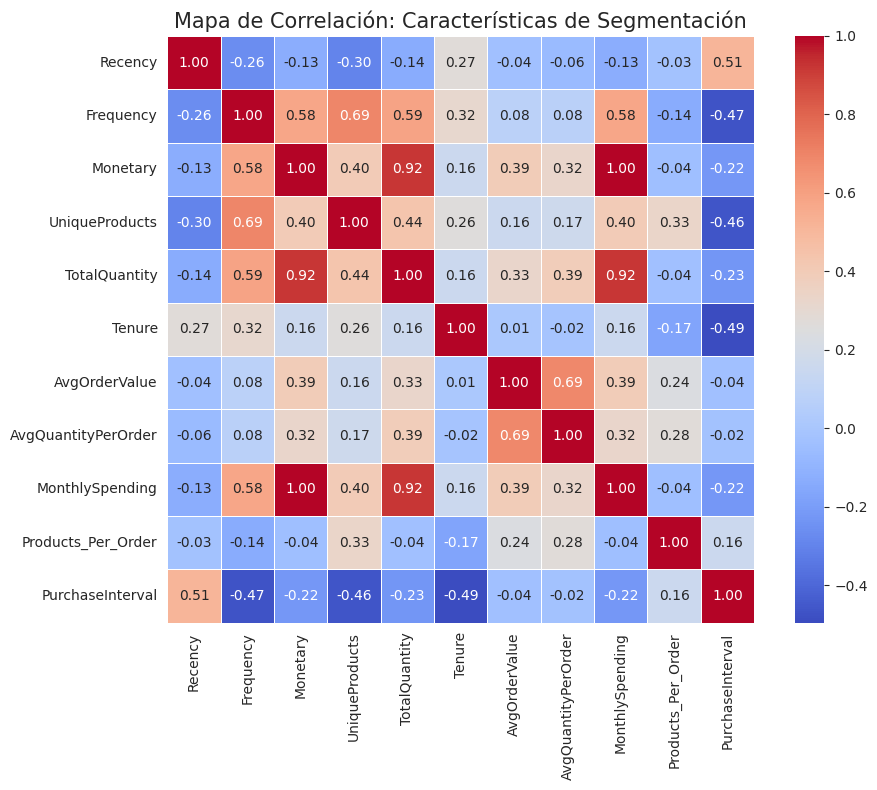

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

########. Generación del Mapa de Correlación

# Calculamos la matriz de correlación de Pearson
corr_matrix = customer_df.corr()

# Configuración visual del gráfico
plt.figure(figsize=(10, 8))

# Crear el heatmap con Seaborn
sns.heatmap(corr_matrix,
            annot=True,           # Muestra los valores numéricos
            cmap='coolwarm',      # Escala de color: Rojo (Positivo), Azul (Negativo)
            fmt=".2f",            # Redondear a 2 decimales
            linewidths=0.5,       # Línea divisoria entre cuadros
            square=True)          # Cuadros perfectamente cuadrados

plt.title('Mapa de Correlación: Características de Segmentación', fontsize=15)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

La matriz de correlación es nuestra brújula estratégica antes del entrenamiento.

Esta herramienta nos dice exactamente qué sobra.

Vemos variables con relación fuerte, cercanas a  1:

- **Monetary y MonthlySpending** tienen una correlación de **1.00**. Esto significa que son la misma variable con distinto nombre. Debemos eliminar una para no sesgar el algoritmo hacia el valor monetario.

- **MonthlySpending y TotalQuantity** tienen un **0.92**. Esto sugiere que, para simplificar el modelo, podríamos quedarnos solo con una.

Eliminamos "monthlySpending" ya que "choca" con las otras dos variables.



In [35]:

# Limpieza final de columnas base que ya que tienen correlacción muy alta (cercana a 1)
columnas_a_borrar = ['MonthlySpending']
customer_df = customer_df.drop(columns=columnas_a_borrar)

display(customer_df)


,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval
CustomerID,,,,,,,,,,
"12,347.00",2,7,"4,310.00",103,2458,367,615.71,351.14,14.71,53.29
"12,348.00",75,4,"1,437.24",21,2332,358,359.31,583.00,5.25,93.25
"12,349.00",18,1,"1,457.55",72,630,18,"1,457.55",630.00,72.00,373.00
"12,350.00",310,1,294.40,16,196,310,294.40,196.00,16.00,373.00
"12,352.00",36,7,"1,385.74",57,526,296,197.96,75.14,8.14,53.29
...,...,...,...,...,...,...,...,...,...,...
"18,280.00",277,1,180.60,10,45,277,180.60,45.00,10.00,373.00
"18,281.00",180,1,80.82,7,54,180,80.82,54.00,7.00,373.00
"18,282.00",7,2,178.05,12,103,126,89.03,51.50,6.00,186.50


## Eliminar los valores de la columna customerID



In [45]:

####### Quitar los valores de la columna customerID, ya que solo meterá ruido
# CustomerID actualmente es el index del dataframe, por lo que reseteamos index para que sea primera columna
customer_df_temp = customer_df.reset_index()
#print(customer_df_temp);

clientes_id = customer_df_temp['CustomerID']
#display(clientes_id);

df_modelo = customer_df_temp.drop(columns=['CustomerID'])
#display(df_modelo);


# Detección de outliers


In [46]:
from sklearn.ensemble import IsolationForest

#  DETECCIÓN DE OUTLIERS CON ISOLATION FOREST

# Isolation Forest detecta clientes con patrones muy diferentes al resto.
# En este caso se marca aproximadamente un 5% de clientes como outliers.
# Estos clientes no se eliminan definitivamente: se guardan aparte para análisis posterior.

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_labels = iso.fit_predict(df_modelo)

# En Isolation Forest:
#  1 = cliente normal
# -1 = cliente outlier
mask_normales = outlier_labels == 1

print("Clientes totales antes de outliers:", df_modelo.shape[0])
print("Clientes normales:", mask_normales.sum())
print("Clientes outliers detectados:", (outlier_labels == -1).sum())
print("Porcentaje outliers:", round((outlier_labels == -1).sum() / df_modelo.shape[0] * 100, 2), "%")

# Guardar los outliers para análisis posterior
df_outliers = df_modelo.loc[~mask_normales].copy()
df_outliers["Outlier_Label"] = -1

# Filtrar clientes normales para el clustering principal
X_modelo_normales = df_modelo.loc[mask_normales].copy()
clientes_id_normales = clientes_id.loc[mask_normales].copy()

print("\nDimensiones tras eliminar outliers:")
print(X_modelo_normales.shape)

display(df_outliers.head())


Clientes totales antes de outliers: 4333
Clientes normales: 4116
Clientes outliers detectados: 217
Porcentaje outliers: 5.01 %

Dimensiones tras eliminar outliers:
(4116, 11)


,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval,Cluster,Outlier_Label
2,18,1,"1,457.55",72,630,18,"1,457.55",630.00,72.00,373.00,0,-1
9,33,1,"6,207.67",131,2708,33,"6,207.67","2,708.00",131.00,373.00,3,-1
11,57,4,"6,310.03",214,1609,331,"1,577.51",402.25,53.50,93.25,3,-1
26,129,1,"4,008.62",219,2529,129,"4,008.62","2,529.00",219.00,373.00,3,-1
40,45,1,"1,435.66",84,1389,45,"1,435.66","1,389.00",84.00,373.00,3,-1


# Normalización y escalado


In [52]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

df_modelo = X_modelo_normales.copy()


# 1. Variables categóricas en las que usarás one-hot-encoding

######### No hay ninguna columna con datos categóricos !!!



# Definimos la lista de columnas numéricas que requieren escalado
numeric_cols = [
    'Recency', 'Frequency', 'Monetary', 'UniqueProducts',
    'TotalQuantity', 'AvgOrderValue', 'AvgQuantityPerOrder',
    'Tenure', 'Products_Per_Order', 'PurchaseInterval'
]

# Filtrar numeric_cols para solo incluir estos en el dataframe para ENTRENAMIENTO MODELO
numeric_cols = [col for col in numeric_cols if col in df_modelo.columns]


# Inicializar el método de escalado habitual RobustScaler
scaler = RobustScaler()

# 2. Escalar todas las variables numéricas para situarlas en un mismo rango
# Utilizamos fit_transform para ajustar el escalador y transformar los datos en un solo paso
df_modelo[numeric_cols] = scaler.fit_transform(df_modelo[numeric_cols])

print("Dataset normalizado y escalado:")
display(df_modelo)

Dataset normalizado y escalado:


,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval,Cluster
0,-0.38,1.67,3.28,1.21,3.05,0.57,1.49,1.19,0.04,-0.48,3
1,0.18,0.67,0.73,-0.23,2.87,0.53,0.37,2.60,-0.55,-0.33,0
3,1.97,-0.33,-0.29,-0.32,-0.22,0.30,0.08,0.25,0.12,0.67,0
4,-0.12,1.67,0.68,0.40,0.26,0.24,-0.34,-0.48,-0.37,-0.48,0
5,1.16,-0.33,-0.47,-0.53,-0.47,-0.19,-0.82,-0.81,-0.62,0.67,0
...,...,...,...,...,...,...,...,...,...,...,...
4328,1.72,-0.33,-0.39,-0.42,-0.43,0.15,-0.42,-0.66,-0.25,0.67,0
4329,0.98,-0.33,-0.48,-0.47,-0.42,-0.30,-0.86,-0.61,-0.44,0.67,0
4330,-0.34,0.00,-0.39,-0.39,-0.35,-0.56,-0.82,-0.62,-0.50,0.00,0
4331,-0.37,4.67,1.26,4.00,1.46,0.43,-0.65,-0.42,0.15,-0.58,0


# Buscar número óptimo de clusters (K) para entrenamiento modelos


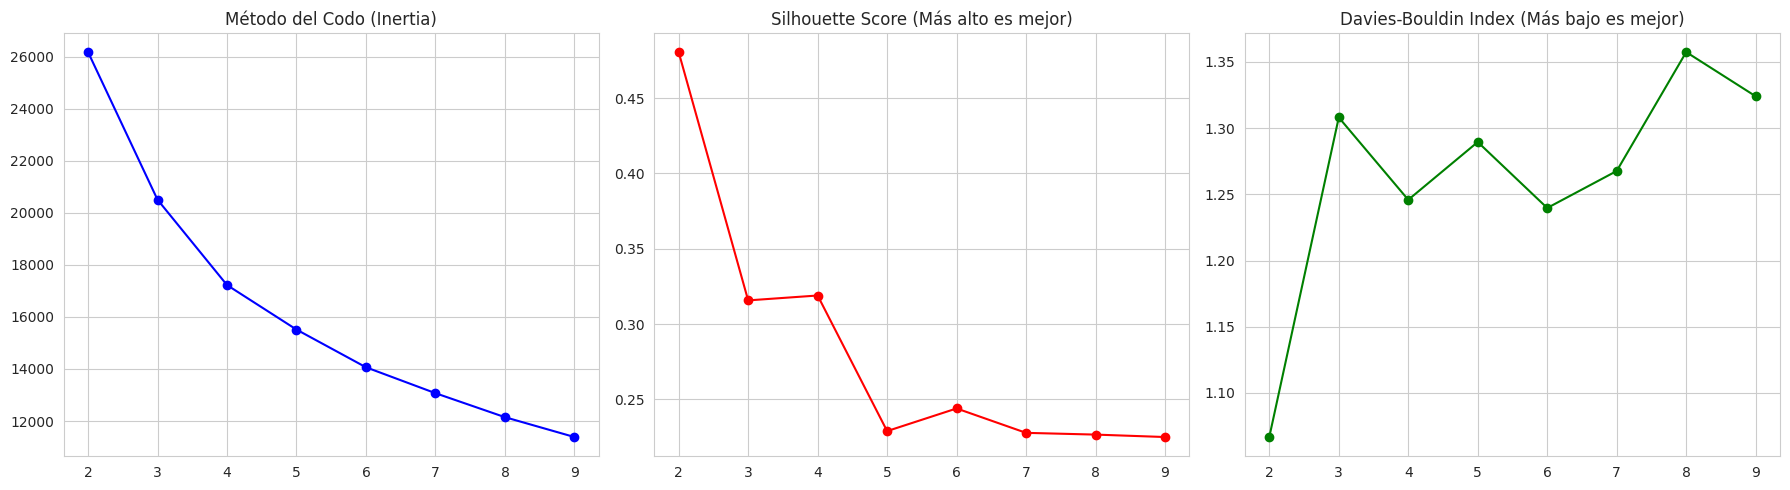

In [53]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

X_train = df_modelo.copy()

# Se calculan métricas para un rango de clusters (2 a 10)
inertia = []
sil_scores = []
db_indices = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train, labels))
    db_indices.append(davies_bouldin_score(X_train, labels))

# Visualización de métricas de diagnóstico
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(K_range, inertia, 'bo-')
ax[0].set_title('Método del Codo (Inertia)')
ax[1].plot(K_range, sil_scores, 'ro-')
ax[1].set_title('Silhouette Score (Más alto es mejor)')
ax[2].plot(K_range, db_indices, 'go-')
ax[2].set_title('Davies-Bouldin Index (Más bajo es mejor)')
plt.tight_layout()
plt.show()

# ENTRENAMIENTO COMPARATIVO DE MODELOS


In [54]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def visualizar_tsne(model_name, X_train, labels, perplexity=30, n_iter=1000):
    """
    Realiza la reducción t-SNE y genera un gráfico 2D.
    """
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=42)
    X_tsne = tsne.fit_transform(X_train)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', s=35, alpha=0.7)
    plt.colorbar(scatter, label='Cluster')
    plt.title(f"{model_name} - Visualización t-SNE 2D", fontsize=15, fontweight='bold')
    plt.xlabel('Eje t-SNE 1')
    plt.ylabel('Eje t-SNE 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return X_tsne

def visualizar_pca_3d_estatico(model_name, X_train, labels):
    """
    Reduce a 3 componentes con PCA y muestra un gráfico 3D estático (Matplotlib).
    """
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_train)

    # Calculamos la varianza explicada
    varianza_explicada = pca.explained_variance_ratio_.sum() * 100
    print(f"-> Varianza explicada por los 3 componentes: {varianza_explicada:.2f}%")

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap='viridis', s=30, alpha=0.6)

    ax.set_title(f'{model_name}: PCA 3D - Estático', fontsize=15)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.set_zlabel('Componente 3')
    plt.show()

    return X_pca


def visualizar_pca_3d_interactivo(model_name, X_train, labels):
    """
    Crea un scatter plot 3D interactivo
    """
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_train)

    # Calculamos la varianza explicada
    varianza_explicada = pca.explained_variance_ratio_.sum() * 100
    print(f"-> Varianza explicada por los 3 componentes: {varianza_explicada:.2f}%")

    # Creamos un DataFrame temporal para Plotly
    df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
    df_pca['Cluster'] = labels.astype(str) # Convertimos a string para colores discretos

    fig = px.scatter_3d(
        df_pca, x='PC1', y='PC2', z='PC3',
        color='Cluster',
        title=f"{model_name}: PCA 3D Interactivo",
        opacity=0.7
    )

    fig.show()

In [55]:
def train_models(models, X_train):
  final_results = []

  for name, model in models.items():
    labels = model.fit_predict(X_train)

    """
      Si el modelo te devuelve estas labels: [0, 0, 1, 1, 1, -1, -1]
        - Unicos: {0, 1, -1} (Hay 3 tipos de etiquetas).
        - ¿Hay ruido?: Sí, si algun -1.
        - Cálculo: 3 - 1 = 2.
      Resultado final: El código te dirá que hay 2 clusters, ignorando los puntos marcados como ruido. Es una forma elegante de obtener el número de grupos "reales" detectados automáticamente.
    """
    mask = labels != -1     # Para métricas de clusters en DBSCAN, excluimos el ruido (-1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Validamos que existan al menos 2 clusters para calcular métricas
    if n_clusters > 1:
        sil = silhouette_score(X_train[mask], labels[mask])
        db = davies_bouldin_score(X_train[mask], labels[mask])
        final_results.append({
            'Modelo': name,
            'Clusters Detectados': n_clusters,
            'Silhouette': round(sil, 4),
            'Davies-Bouldin': round(db, 4),
            'etiquetas': labels
        })

        # VISUALIZACIONES
        visualizar_tsne(name, X_train, labels, perplexity=30, n_iter=1000)
        visualizar_pca_3d_interactivo(name, X_train, labels)

    else:
        final_results.append({
            'Modelo': name,
            'Clusters Detectados': n_clusters,
            'Silhouette': 'N/A',
            'Davies-Bouldin': 'N/A'
        })


  # Resultado Final en DataFrame
  df_comparativa = pd.DataFrame(final_results)
  print(df_comparativa)

  return final_results


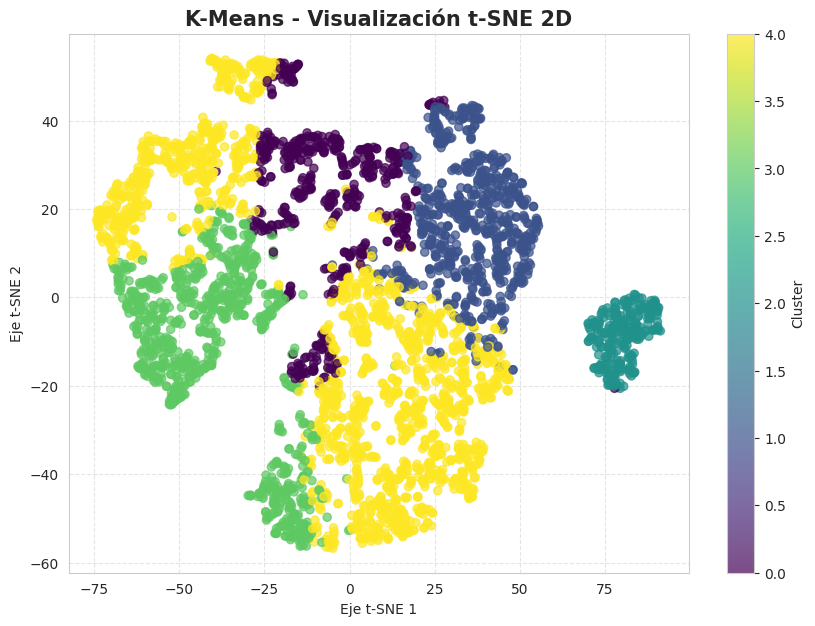

-> Varianza explicada por los 3 componentes: 82.45%


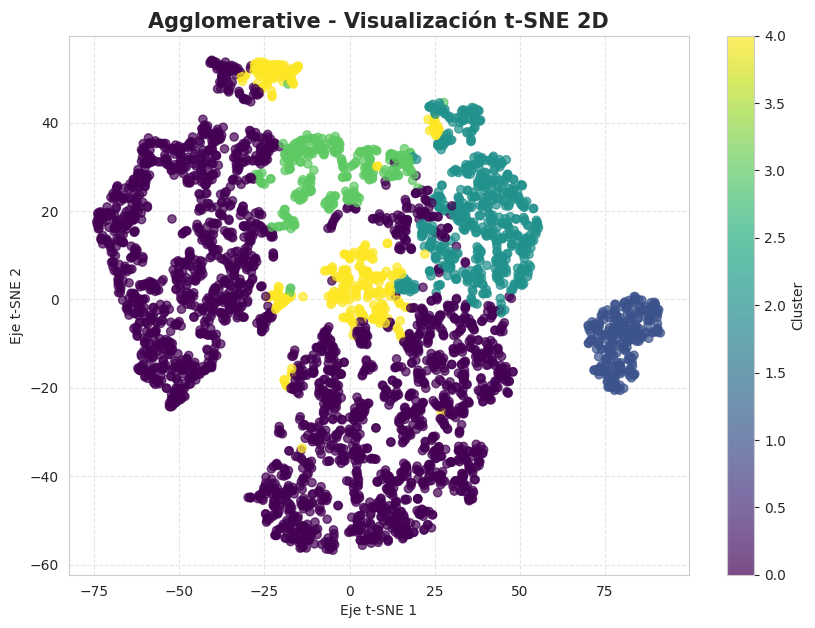

-> Varianza explicada por los 3 componentes: 82.45%


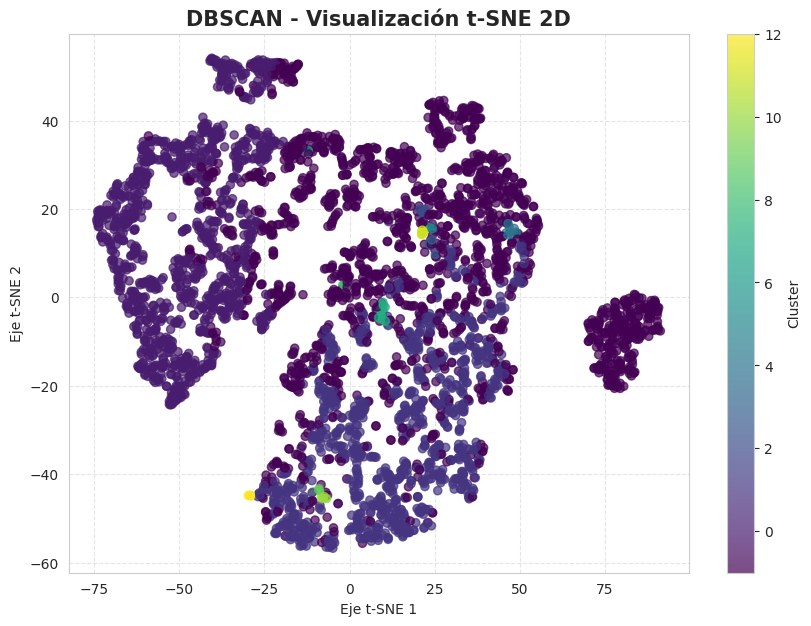

-> Varianza explicada por los 3 componentes: 82.45%


          Modelo  Clusters Detectados  Silhouette  Davies-Bouldin                                          etiquetas
0        K-Means                    5        0.23            1.29  [2, 1, 3, 1, 3, 0, 3, 0, 4, 0, 3, 2, 4, 1, 3, ...
1  Agglomerative                    5        0.29            1.19  [1, 2, 0, 0, 0, 3, 0, 3, 0, 3, 0, 1, 0, 0, 0, ...
2         DBSCAN                   13       -0.11            1.02  [-1, -1, 0, 1, 0, -1, 0, -1, -1, -1, 0, -1, 1,...


In [56]:
# Configuramos los tres modelos solicitados

K=5

models = {
    'K-Means': KMeans(n_clusters=K, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=K),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5) # Parámetros ajustables según densidad
}

models_results = train_models(models, X_train);


### interpretación técnica de lo que está ocurriendo con tus datos:


## K=5


## Mejorar DBScan

In [41]:
# --- TÉCNICA DE MEJORA: TRANSFORMACIÓN LOGARÍTMICA ---
# DBSCAN sufre cuando hay mucha diferencia de densidad. El logaritmo "aplasta"
# los valores grandes (outliers) y acerca a los clientes entre sí.

# features = ['Monetary', 'Frequency', 'Recency', 'AvgOrderValue', 'Tenure']
X_log = df_modelo.copy()

# Aplicamos log(1+x) para manejar ceros y normalizar la distribución
for col in numeric_cols:
    X_log[col] = np.log1p(X_log[col])

# Imputamos los valores NaN que puedan haber surgido de la transformación logarítmica
# Esto es crucial porque DBSCAN no puede manejar NaNs.
X_log.fillna(X_log.median(), inplace=True)

# 2. ESCALADO ROBUSTO
scaler = RobustScaler()
X_scaled_log = scaler.fit_transform(X_log)

# 3. ENTRENAMIENTO DBSCAN
# Al normalizar con logaritmos, ahora podemos usar un 'eps' más pequeño
db_log = DBSCAN(eps=0.8, min_samples=15)
labels_log = db_log.fit_predict(X_scaled_log)

# 4. ANÁLISIS DE RESULTADOS
n_clusters = len(set(labels_log)) - (1 if -1 in labels_log else 0)
n_ruido = list(labels_log).count(-1)

print(f"Clusters detectados: {n_clusters}")
print(f"Puntos de ruido: {n_ruido}")

if n_clusters > 1:
    mask = labels_log != -1
    sil = silhouette_score(X_scaled_log[mask], labels_log[mask])
    print(f"Silhouette (sin ruido): {round(sil, 4)}")

Clusters detectados: 2
Puntos de ruido: 801
Silhouette (sin ruido): 0.2425


# Interpretación de los datos de cada cluster. Tipo de clientes -> En archivo Word

### CREAMOS columna "Cluster" para poder diferenciar los datos de cada uno


In [58]:
# CREAMOS columna "Cluster" para poder diferenciar los datos de cada uno

kmeans = models['K-Means']

# Filter customer_df to include only the normal customers (non-outliers)
# to match the length of X_train and the output of kmeans.fit_predict
customer_df_filtered = customer_df[customer_df.index.isin(clientes_id_normales)]

# Now assign the cluster labels to the filtered DataFrame
customer_df_filtered['Cluster'] = kmeans.fit_predict(X_train)

# PERFILAMIENTO E INTERPRETACIÓN
# ==========================================

# Calculamos las medias de los datos reales para entender cada grupo
perfilamiento = customer_df_filtered.groupby('Cluster').agg({ # Use customer_df_filtered
    'Monetary': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean',
    'AvgOrderValue': 'mean',
    'Tenure': 'mean'
}).round(2)

perfilamiento['NumClientes'] = customer_df_filtered.groupby('Cluster').size() # Use customer_df_filtered

print("--- Resumen de los Clusters ---")
print(perfilamiento)



# VISUALIZACIÓN INTERACTIVA (PCA 3D)
# ==========================================
# X_pca is already computed from X_train, which is the normal customers.
# So, pca_df should be created with the cluster labels from customer_df_filtered
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train) # X_train is already filtered
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Cluster'] = customer_df_filtered['Cluster'].values.astype(str) # Use customer_df_filtered

fig = px.scatter_3d(
    pca_df, x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title="Mapa de Segmentación de Clientes (Interactiva)",
    opacity=0.7,
    template="plotly_white"
)

fig.show()


# IMPORTANTE: Usamos reset_index() para que el CustomerID pase de ser
# un 'índice' a una columna normal antes de guardar.
df_final_exportar = customer_df_filtered.reset_index() # Use customer_df_filtered

# Usamos astype(int) para eliminar los decimales (.0)
df_final_exportar['CustomerID'] = df_final_exportar['CustomerID'].astype(int)
display(df_final_exportar)


# EXPORTACIÓN DE RESULTADOS
# ==========================================
df_final_exportar.to_csv('clientes_segmentados_final.csv')
print("\nArchivo 'clientes_segmentados_final.csv' guardado con éxito.")

--- Resumen de los Clusters ---
         Monetary  Frequency  Recency  AvgOrderValue  Tenure  NumClientes
Cluster                                                                  
0        1,117.66       1.75    94.77         662.70  160.61          517
1        2,128.29       6.84    33.76         337.27  295.88          723
2        5,286.21      12.32    17.43         498.02  328.92          259
3          290.94       1.38   255.33         219.58  277.05          865
4          535.73       2.34    51.31         236.80  161.26         1752


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval,Cluster
0,12347,2,7,"4,310.00",103,2458,367,615.71,351.14,14.71,53.29,2
1,12348,75,4,"1,437.24",21,2332,358,359.31,583.00,5.25,93.25,1
2,12350,310,1,294.40,16,196,310,294.40,196.00,16.00,373.00,3
3,12352,36,7,"1,385.74",57,526,296,197.96,75.14,8.14,53.29,1
4,12353,204,1,89.00,4,20,204,89.00,20.00,4.00,373.00,3
...,...,...,...,...,...,...,...,...,...,...,...,...
4111,18280,277,1,180.60,10,45,277,180.60,45.00,10.00,373.00,3
4112,18281,180,1,80.82,7,54,180,80.82,54.00,7.00,373.00,3
4113,18282,7,2,178.05,12,103,126,89.03,51.50,6.00,186.50,4
4114,18283,3,16,"2,039.58",262,1355,337,127.47,84.69,16.38,23.31,1



Archivo 'clientes_segmentados_final.csv' guardado con éxito.


# Identificación de los clientes de cada cluster

In [59]:
df = df_final_exportar.copy()

# Supongamos que 'df' es tu DataFrame original con la columna 'Cluster'
# 1. Obtenemos la lista de clusters únicos y los ordenamos
clusters_unicos = sorted(df['Cluster'].unique())

for cluster_id in clusters_unicos:
  print(f"\n" + "="*30)
  print(f" ANALIZANDO EL CLUSTER: {cluster_id}")
  print("="*30)

  # Ahora la selección de clientes para el cluster actual es correcta
  clientes_cluster = df[df['Cluster'] == cluster_id][['CustomerID', 'Monetary', 'Frequency', 'Recency', 'AvgOrderValue']]

  # 3. Ordenamos por gasto (Monetary) de mayor a menor para que coincida con tu lista
  clientes_cluster = clientes_cluster.sort_values(by='Monetary', ascending=False)

  # 4. Formateamos la salida para que sea más legible (opcional)
  # Renombramos columnas para que coincidan exactamente con nuestra descripción
  clientes_cluster.columns = [
      'CustomerID',
      'Gasto Total-(Monetary) (£)',
      'Pedidos cant.-(Frequency)',
      'Días Inactivo-(Recency)',
      'Ticket Promedio (£)'
  ]

  # Mostramos los resultados
  display(clientes_cluster.head(10)) # Display top 10 customers for each cluster for brevity

  # clientes_cluster.to_csv('top_5_clientes.csv', index=False)


 ANALIZANDO EL CLUSTER: 0


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
2402,15808,"3,651.27",4,306,912.82
73,12449,"3,596.29",4,22,899.07
710,13373,"3,312.25",3,60,"1,104.08"
1255,14175,"3,222.30",3,59,"1,074.10"
1717,14844,"3,189.81",4,63,797.45
2557,16041,"3,166.40",3,30,"1,055.47"
1865,15065,"3,158.13",4,37,789.53
190,12613,"3,092.38",4,57,773.10
3732,17728,"2,876.01",3,3,958.67
1218,14121,"2,780.15",4,3,695.04



 ANALIZANDO EL CLUSTER: 1


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
3274,17061,"5,232.23",11,73,475.66
1335,14292,"4,871.93",9,7,541.33
233,12664,"4,391.88",9,8,487.99
3874,17937,"4,301.22",7,8,614.46
292,12747,"4,196.01",11,2,381.46
2509,15971,"4,194.90",12,17,349.57
68,12444,"4,085.46",5,21,817.09
293,12749,"4,040.88",5,3,808.18
3231,17001,"3,989.57",11,0,362.69
307,12779,"3,981.36",8,37,497.67



 ANALIZANDO EL CLUSTER: 2


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
3076,16779,"10,611.72",22,2,482.35
3715,17706,"10,504.49",17,4,617.91
1181,14062,"10,464.85",12,9,872.07
3818,17865,"10,422.22",19,30,548.54
2264,15615,"10,399.74",23,10,452.16
453,13001,"9,785.97",13,4,752.77
762,13458,"9,646.57",14,7,689.04
1645,14733,"9,585.91",12,16,798.83
2896,16523,"9,418.47",21,1,448.50
263,12709,"9,400.52",15,15,626.70



 ANALIZANDO EL CLUSTER: 3


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
2062,15332,"1,661.06",4,366,415.26
432,12967,"1,660.90",2,358,830.45
3064,16766,"1,145.60",2,273,572.80
1015,13819,"1,140.35",3,301,380.12
3009,16692,"1,126.00",2,256,563.00
362,12857,"1,106.40",2,210,553.20
1246,14161,"1,097.62",3,215,365.87
941,13715,"1,064.49",5,281,212.90
2380,15777,"1,047.11",4,241,261.78
1454,14465,"1,038.44",3,246,346.15



 ANALIZANDO EL CLUSTER: 4


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
1329,14285,"1,910.01",4,21,477.50
1282,14216,"1,839.30",4,3,459.82
1559,14608,"1,785.15",4,4,446.29
335,12823,"1,759.50",5,74,351.90
2017,15267,"1,717.36",5,22,343.47
1437,14441,"1,712.89",4,0,428.22
2996,16671,"1,692.27",3,28,564.09
2095,15380,"1,690.26",5,8,338.05
3331,17152,"1,689.50",3,194,563.17
395,12912,"1,662.30",5,2,332.46
